## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout
import warnings
warnings.filterwarnings("ignore", message="Using UFloat objects with std_dev==0*")


# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def MTplotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")
    global model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan  

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # FIT DATA
    # time-mask 4 fitting
    tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
    x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]
    
    # compute and save the fit
    fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
    g2fit.loc[0] = [Q_notebook, dQ_notebook,
                    fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                    fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                    fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                    fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                    fit.redchi,]
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", index=False)
    
    # print fit report
    display(g2fit)

    # PLOT FIT AND RESIDUALS IN SUBPLOTS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, sharex=True)

    # Main fit plot
    ax1.errorbar(g2[0], g2[1], yerr=g2[2], c='C0', marker='o', linestyle='None')
    xfit = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
    yfit = fit.eval(t=xfit)
    ax1.plot(xfit, yfit, c='black', linestyle='--')
    if t1_fit != 0:
        ax1.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit != 1e100:
        ax1.axvline(t2_fit, color='red', linestyle='--')
    ax1.set_ylabel('g2')
    ax1.set_xscale('log')
    ax1.set_ylim(bottom=1, top=np.max(g2[1] + g2[2]))

    # Residuals plot
    residuals = (g2[1] - fit.eval(t=g2[0]))/ g2[2]
    ax2.scatter(g2[0], residuals, color='C0')
    ax2.axhline(0, color='black', linestyle='-')
    ax2.axhline(1, color='black', linestyle='--')
    ax2.axhline(-1, color='black', linestyle='--')
    ax2.set_xlabel('t [s]')
    ax2.set_ylabel('Res/$\\sigma$')
    ax2.set_xscale('log')

    plt.setp(ax1.get_xticklabels(), visible=False)

    return fig, ax1, ax2

### Load masks

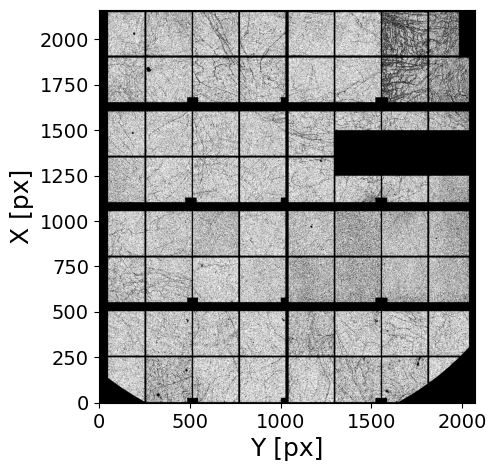

In [3]:
### e4m MASKS
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

# XPCS scans @ 9.7keV

### Beamstop mask

In [22]:
#######################################
sample_name = 'GeO2_4_30C'
Ndataset = 2
Nscan = 4
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1200192
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.01 s)
Concatenating vectors ...
Done! (elapsed time = 0.0 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_4_30C/GeO2_4_30C_0002/scan0004/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     1.4e-04
	 | Memory usage (scipy.csr_array): 0.007 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 246.0
# of pixels above Ith_high treshold ->  581240 pixels (of 4471016 => 13.0 %)
################################################################################



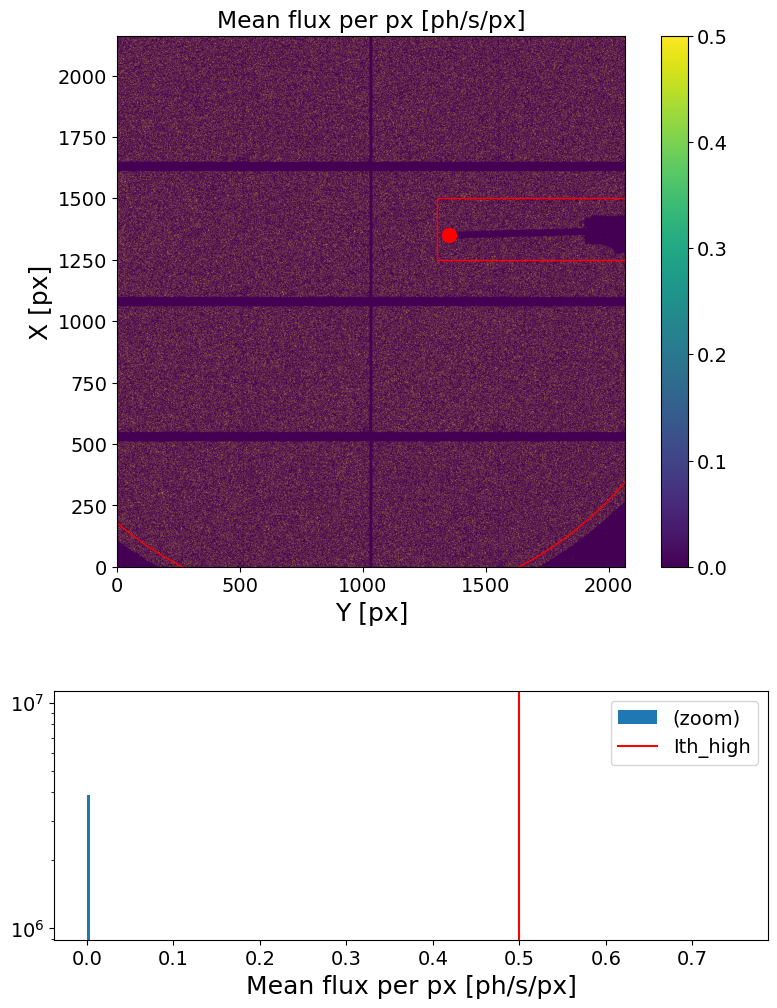

In [5]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



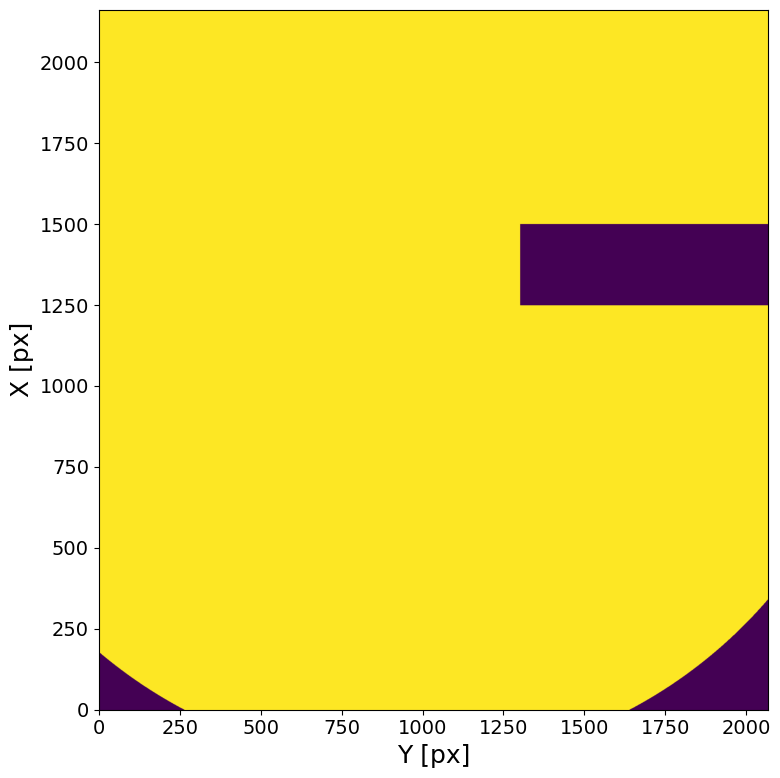

In [6]:
bs_mask_97 = XPCS.gen_mask(mask_geom=geom)

### Q mask

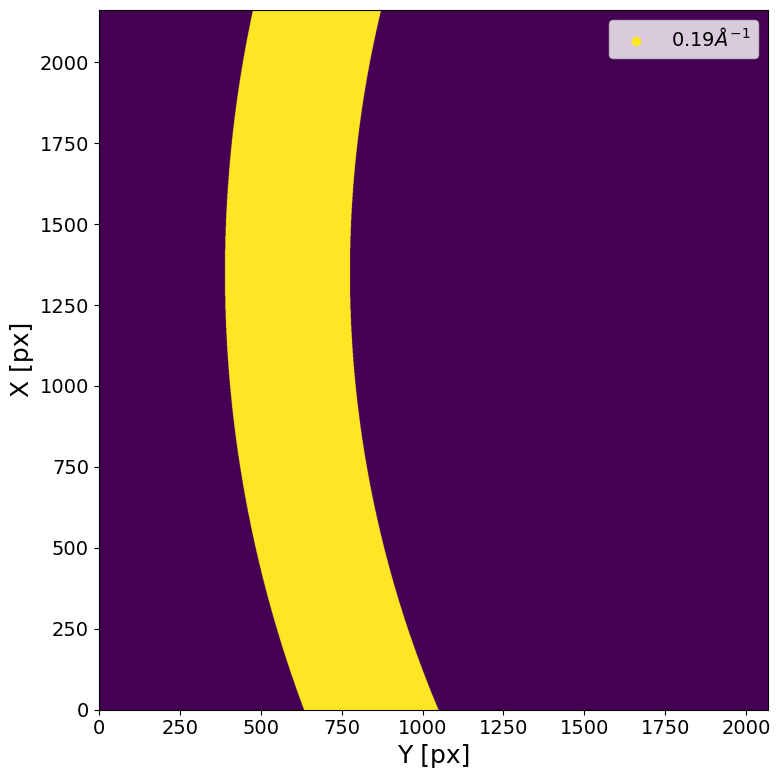

In [7]:
###################
Q_notebook = .19 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask_97 = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

## XPCS scan: Ei=9.7keV, T=30C, Q=0.19, 20min @ 1ms (GeO2_4_30C, dataset 2, scan 3)

In [8]:
#######################################
sample_name = 'GeO2_4_30C'
Ndataset = 2
Nscan = 4
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_97 * Qmask_97 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
th = 2.3999999999999986
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



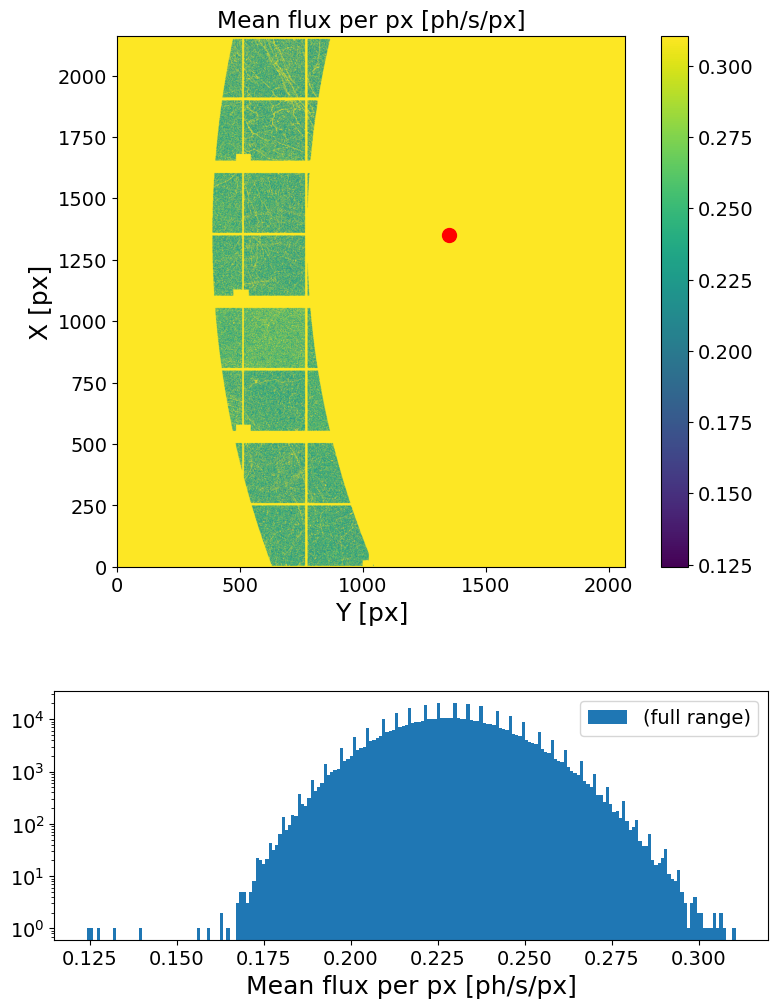

In [9]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [10]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

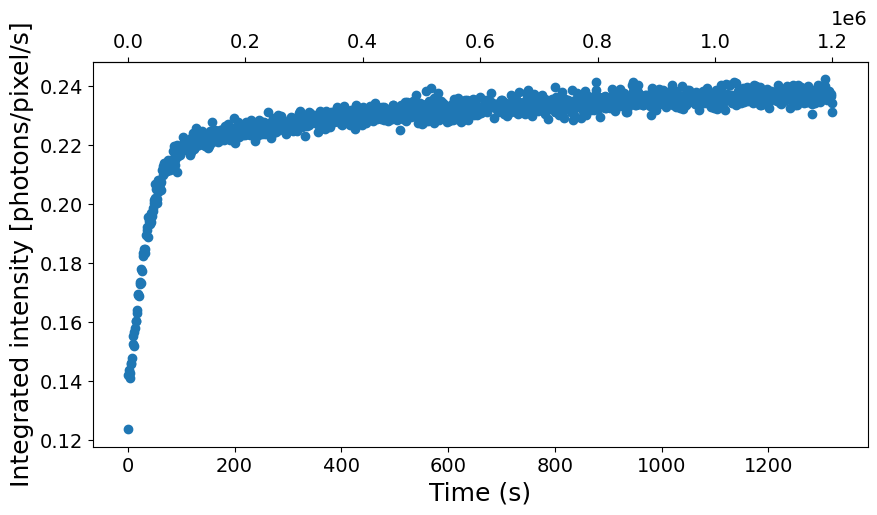

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [12]:
##### INPUTS #####
Nfi = int(.6e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1189824 => (Nff-Nfi) = 36*2^sparse_depth, thrown frames = 10367 (1.73%)
Loading frames ...


Done! (elapsed time = 0.92 s)
	 | 589824 frames X 551010 pixels
	 | sparsity = 2.59e-04
	 | memory usage (sparse.csr_array @ float32) = 0.944 GB
Computing sparse multitau G2t...


100%|██████████| 36/36 [00:44<00:00,  1.23s/it]


Done! (elapsed time = 44.44 s)
Computing dense multitau G2t...
	-> computing channels on 288 frames ...
	-> computing channels on 144 frames ...
	-> computing channels on 72 frames ...
	-> computing channels on 36 frames ...
	-> computing channels on 18 frames ...
Done! (elapsed time = 3.95 s)


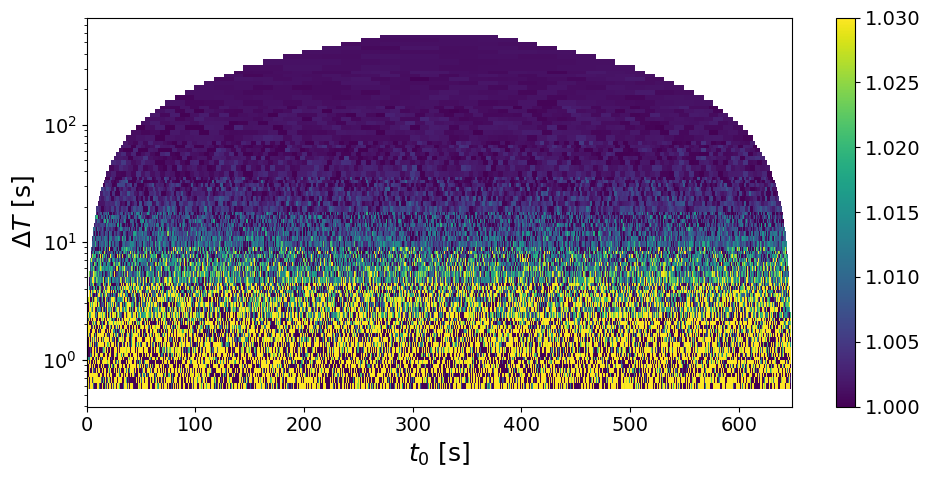

In [13]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,6.177408,0.142377,2.304802,0.812486,0.015385,1.893581,0.030324,0.000425,1.401325,1.001228,0.000014,0.001415,1.469972


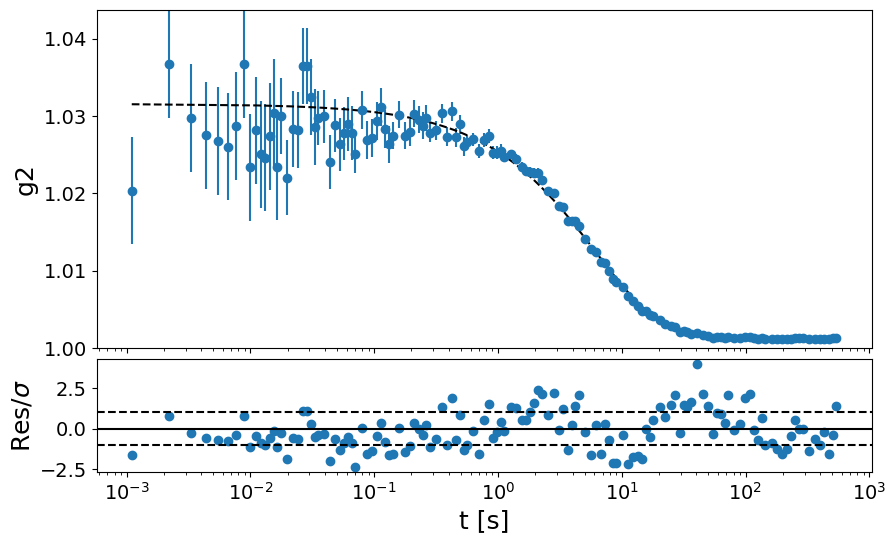

In [14]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=9.7keV, att=.5, T=30C, Q=0.19, 20min @ 1ms (GeO2_4_30C, dataset 2, scan 5)

In [15]:
#######################################
sample_name = 'GeO2_4_30C'
Ndataset = 2
Nscan = 5
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_97 * Qmask_97 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 2400384
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
th = 2.3999999999999986
T = 44.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/481 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/481 loops)
	 -> loading file eiger4m_v

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



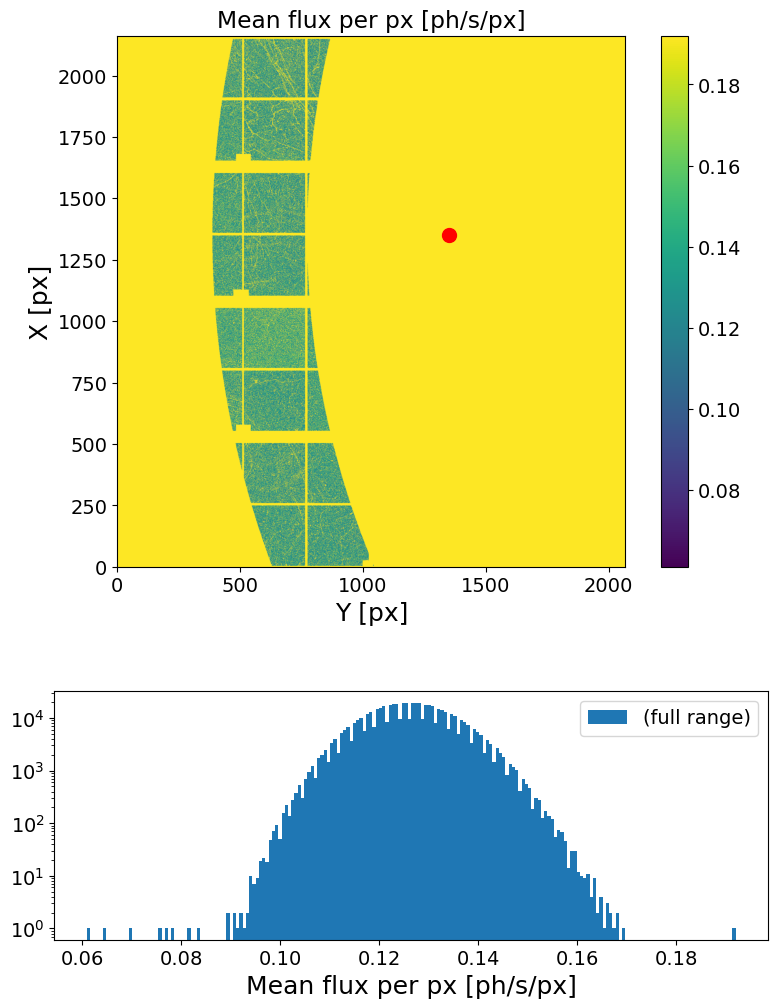

In [16]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [17]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

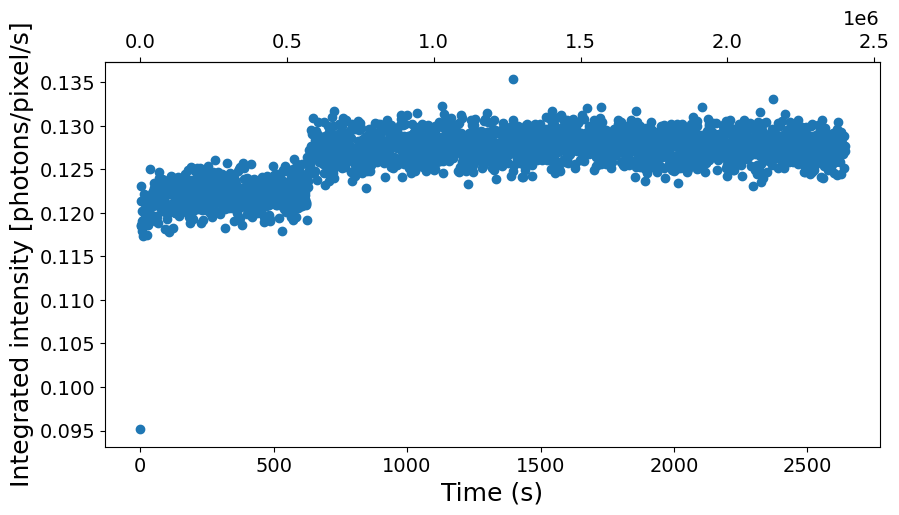

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [19]:
##### INPUTS #####
Nfi = int(.6e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 2385856 => (Nff-Nfi) = 109*2^sparse_depth, thrown frames = 14527 (0.81%)
Loading frames ...
Done! (elapsed time = 1.05 s)
	 | 1785856 frames X 551010 pixels
	 | sparsity = 1.40e-04
	 | memory usage (sparse.csr_array @ float32) = 1.558 GB
Computing sparse multitau G2t...


100%|██████████| 109/109 [01:47<00:00,  1.01it/s]


Done! (elapsed time = 107.73 s)
Computing dense multitau G2t...
	-> computing channels on 872 frames ...
	-> computing channels on 436 frames ...
	-> computing channels on 218 frames ...
	-> computing channels on 109 frames ...
	-> computing channels on 54 frames ...
	-> computing channels on 27 frames ...
Done! (elapsed time = 12.61 s)


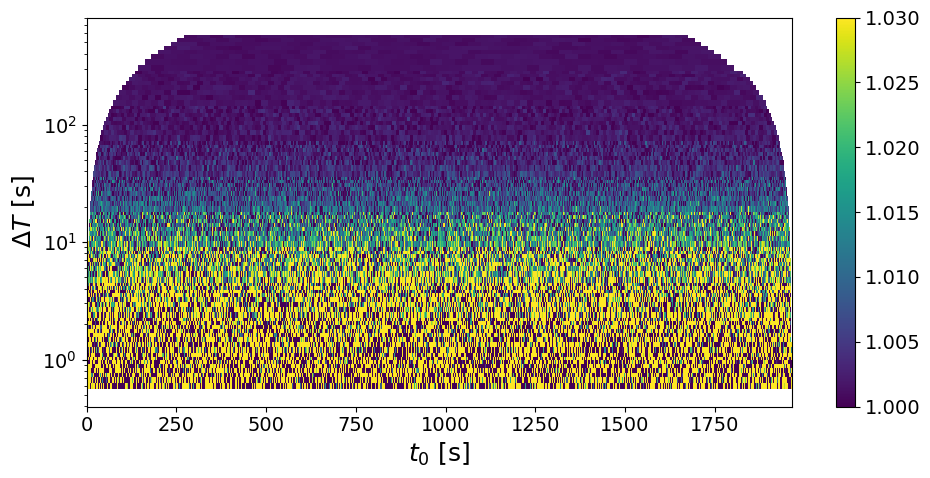

In [20]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,13.184594,0.258423,1.96004,0.825224,0.013601,1.648134,0.030969,0.000372,1.202183,1.00126,0.000013,0.001306,2.160513


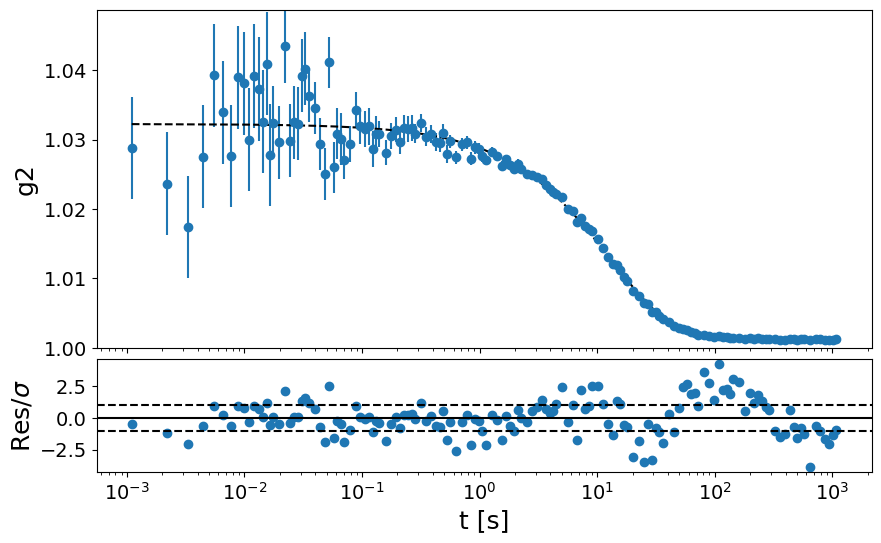

In [21]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=30)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

# XPCS scans @ 10.25keV

### Beamstop mask

In [22]:
#######################################
sample_name = 'GeO2_4_10p25'
Ndataset = 1
Nscan = 14
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 3599664
Ei = 10.25000164635837
itime = 0.0011
theta = 1.7500000000000004
Q = 0.16
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 30.54 s)
Concatenating vectors ...
Done! (elapsed time = 0.0 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_4_10p25/GeO2_4_10p25_0001/scan0014/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     2.0e-04
	 | Memory usage (scipy.csr_array): 0.010 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 249.0
# of pixels above Ith_high treshold ->  791431 pixels (of 4471016 => 17.7 %)
################################################################################



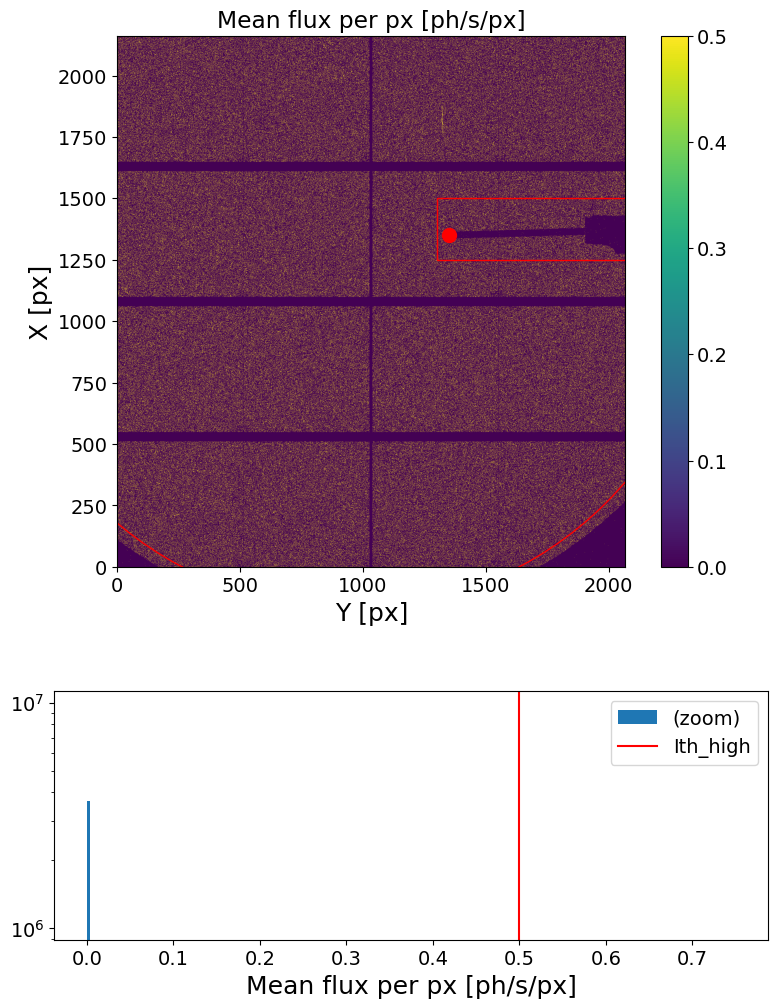

In [23]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



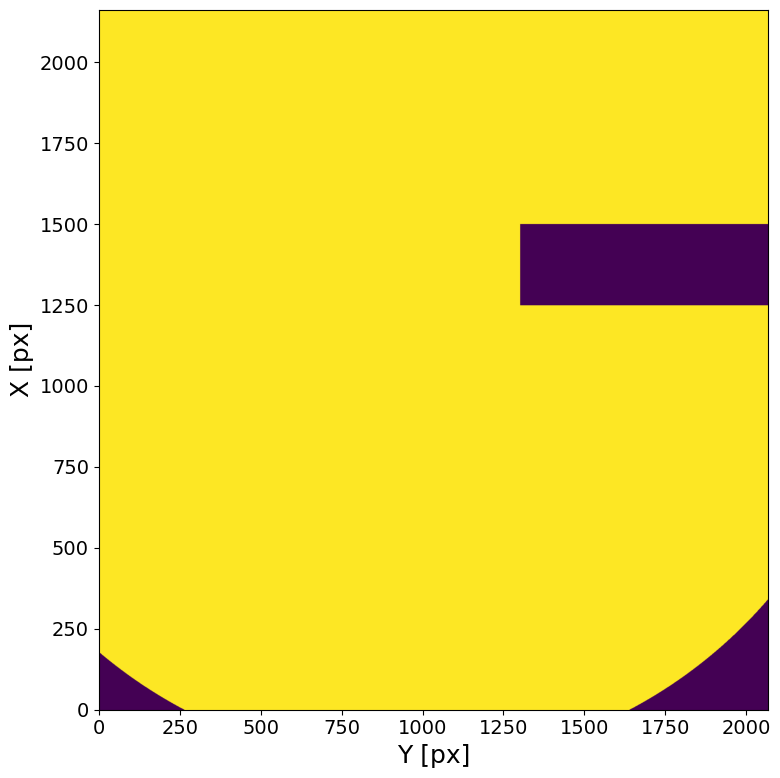

In [24]:
bs_mask_1025 = XPCS.gen_mask(mask_geom=geom)

### Q mask

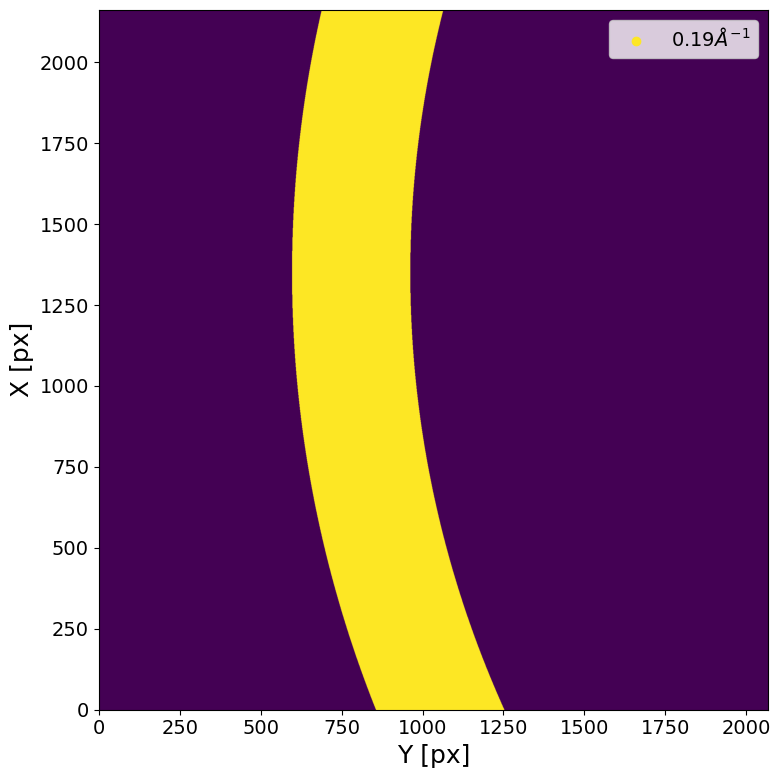

In [25]:
###################
Q_notebook = .19 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask_1025 = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

## XPCS scan: Ei=10.25keV, T=30C, Q=0.16, th=0, 50min @ 1ms ON fp (GeO2_4_10p25, dataset 1, scan 14)

In [26]:
#######################################
sample_name = 'GeO2_4_10p25'
Ndataset = 1
Nscan = 14
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_1025 * Qmask_1025 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 10.25000164635837
itime = 0.0011
theta = 1.7500000000000004
Q = 0.16
th = 0.0
T = 57.13 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/624 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



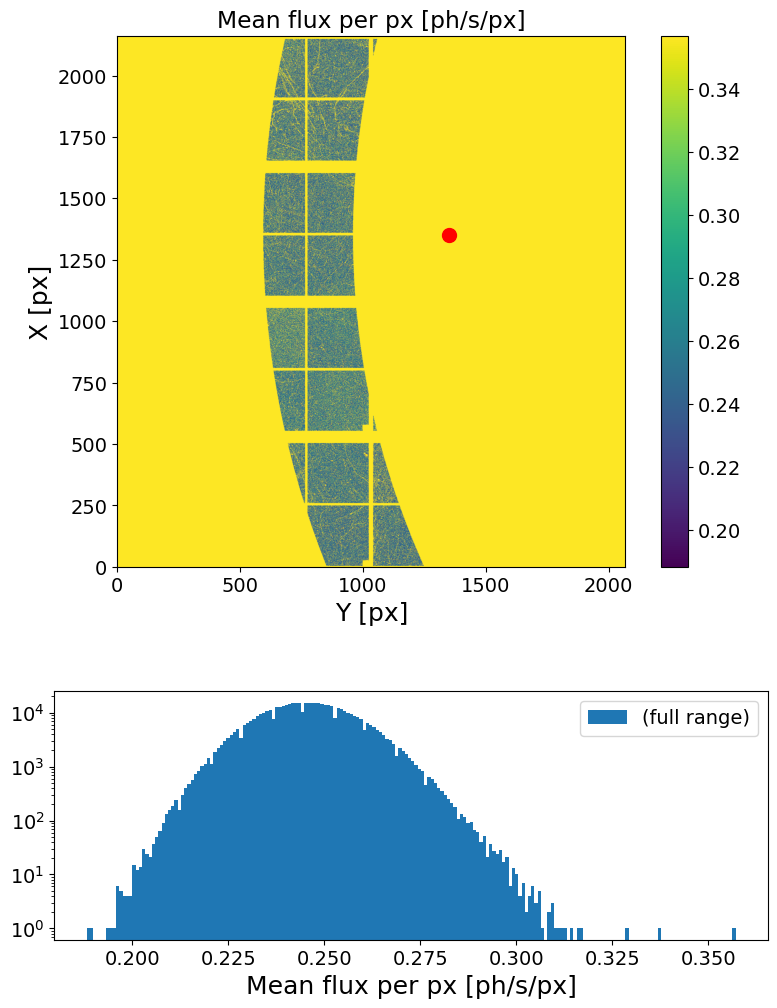

In [27]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [28]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

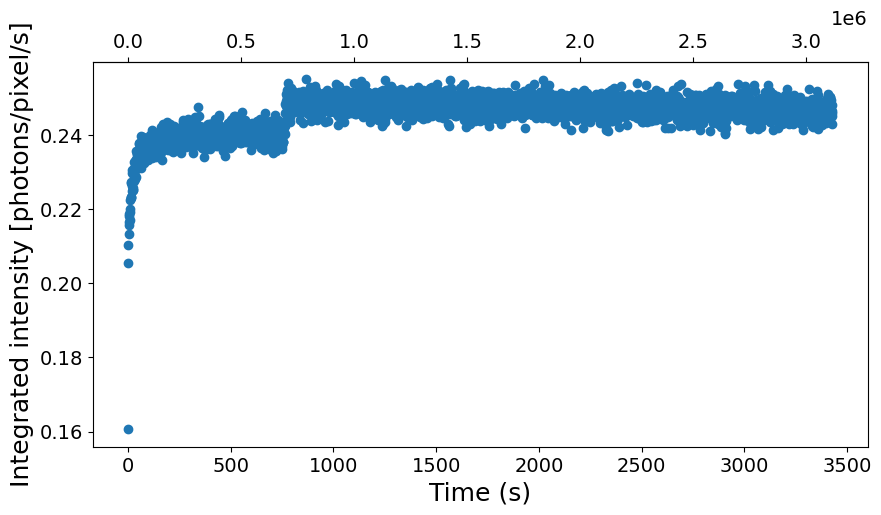

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [30]:
##### INPUTS #####
Nfi = int(.4e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 3103360 => (Nff-Nfi) = 165*2^sparse_depth, thrown frames = 12963 (0.48%)
Loading frames ...
Done! (elapsed time = 9.87 s)
	 | 2703360 frames X 528008 pixels
	 | sparsity = 2.72e-04
	 | memory usage (sparse.csr_array @ float32) = 4.355 GB
Computing sparse multitau G2t...


100%|██████████| 165/165 [04:22<00:00,  1.59s/it]


Done! (elapsed time = 263.01 s)
Computing dense multitau G2t...
	-> computing channels on 1320 frames ...
	-> computing channels on 660 frames ...
	-> computing channels on 330 frames ...
	-> computing channels on 165 frames ...
	-> computing channels on 82 frames ...
	-> computing channels on 41 frames ...
	-> computing channels on 20 frames ...
Done! (elapsed time = 29.24 s)


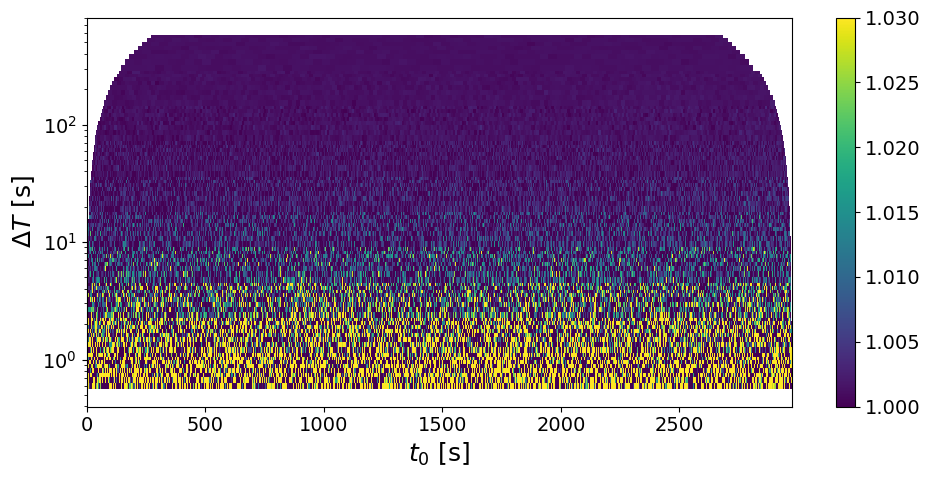

In [31]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.112468,0.017115,15.21773,0.430832,0.019744,4.58283,0.168826,0.010267,6.081137,1.001222,0.000014,0.001395,30.354572


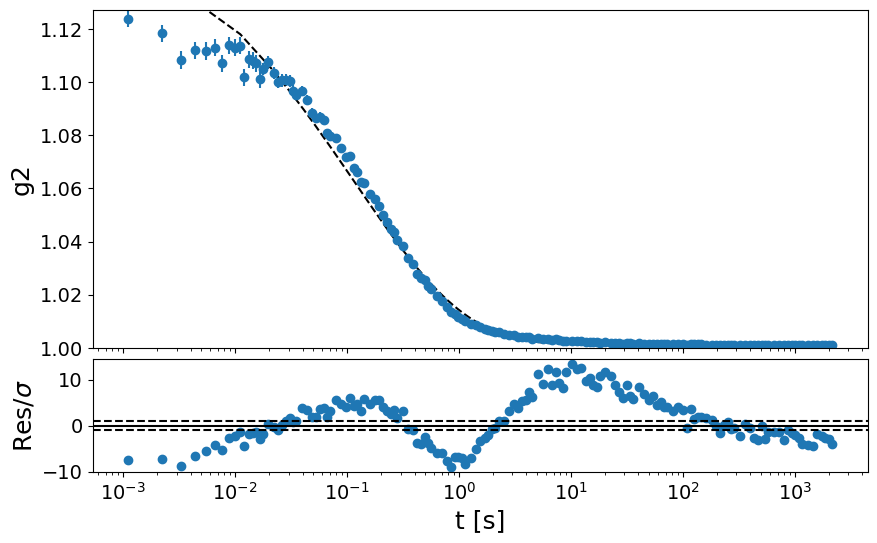

In [32]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=10.25keV, T=30C, Q=0.16, th=0, 20min @ 1ms ON fp (GeO2_4_10p25, dataset 1, scan 15)

In [33]:
#######################################
sample_name = 'GeO2_4_10p25'
Ndataset = 1
Nscan = 15
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_1025 * Qmask_1025 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 10.25000164635837
itime = 0.0011
theta = 1.7500000000000004
Q = 0.16
th = 0.0
T = 26.16 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/286 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



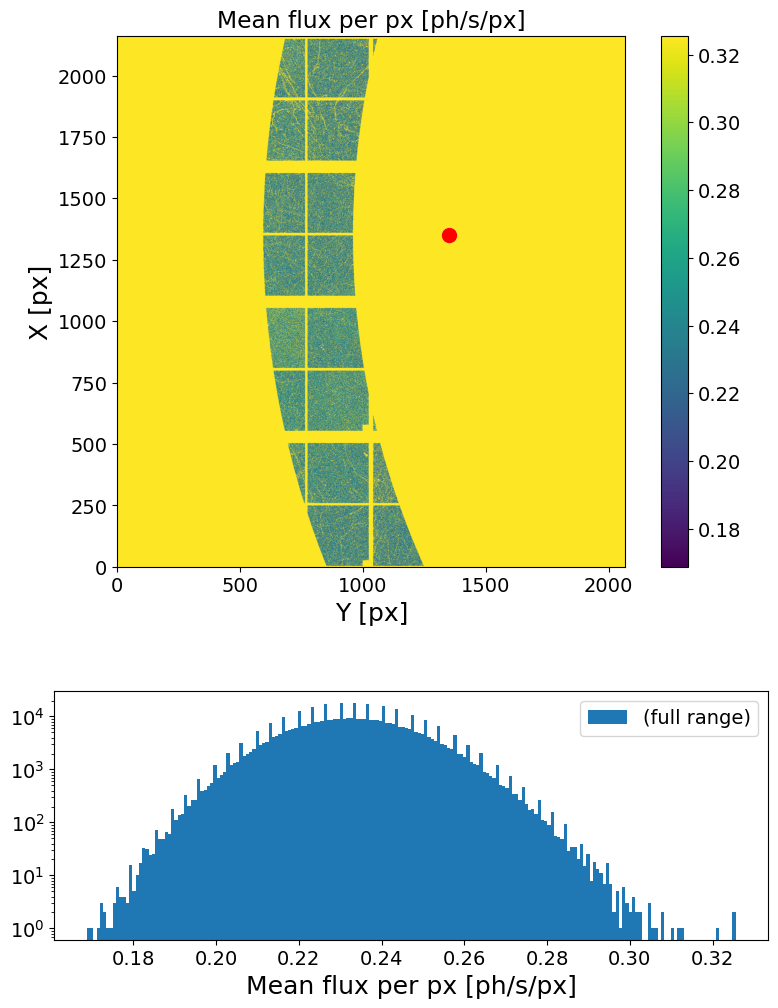

In [34]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [35]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

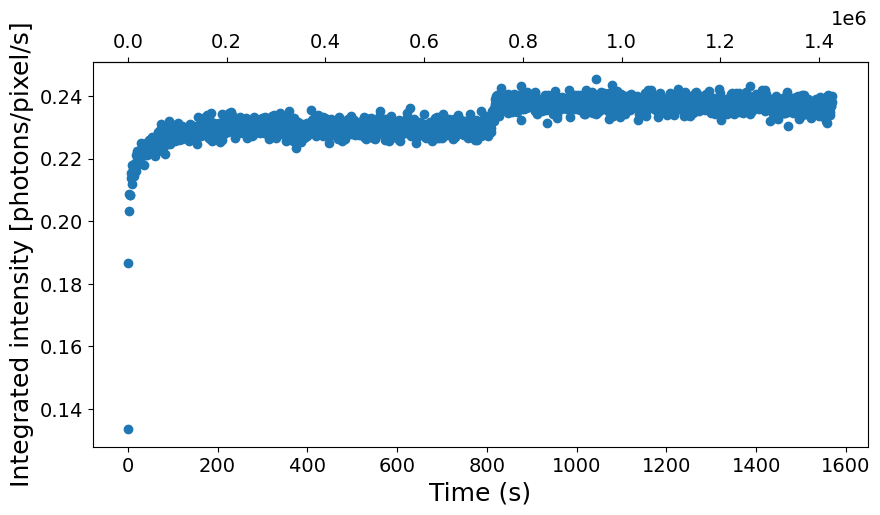

In [36]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [37]:
##### INPUTS #####
Nfi = int(.2e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1412416 => (Nff-Nfi) = 74*2^sparse_depth, thrown frames = 14621 (1.19%)
Loading frames ...
Done! (elapsed time = 3.53 s)
	 | 1212416 frames X 528008 pixels
	 | sparsity = 2.58e-04
	 | memory usage (sparse.csr_array @ float32) = 1.852 GB
Computing sparse multitau G2t...


100%|██████████| 74/74 [02:20<00:00,  1.90s/it]


Done! (elapsed time = 140.55 s)
Computing dense multitau G2t...
	-> computing channels on 592 frames ...
	-> computing channels on 296 frames ...
	-> computing channels on 148 frames ...
	-> computing channels on 74 frames ...
	-> computing channels on 37 frames ...
	-> computing channels on 18 frames ...
Done! (elapsed time = 12.37 s)


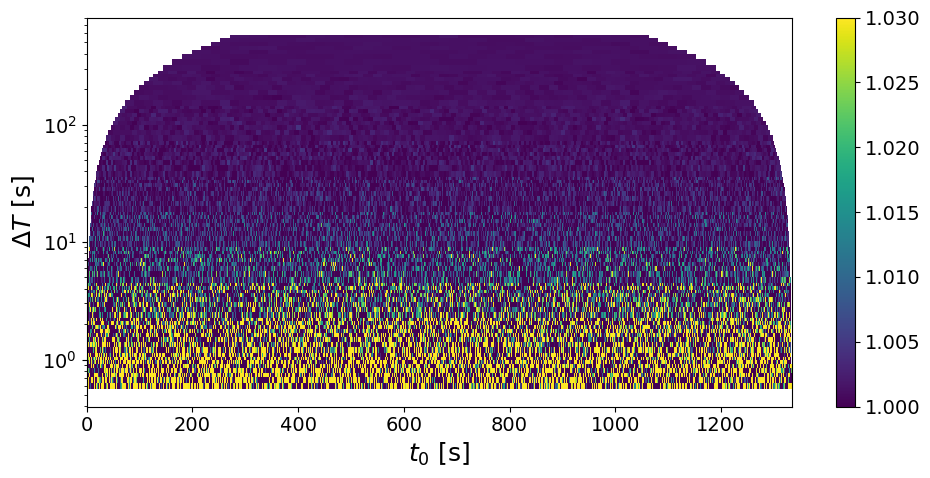

In [38]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.207074,0.006982,3.371696,0.699627,0.016442,2.350127,0.120972,0.002331,1.926912,1.00325,0.000139,0.013833,1.888954


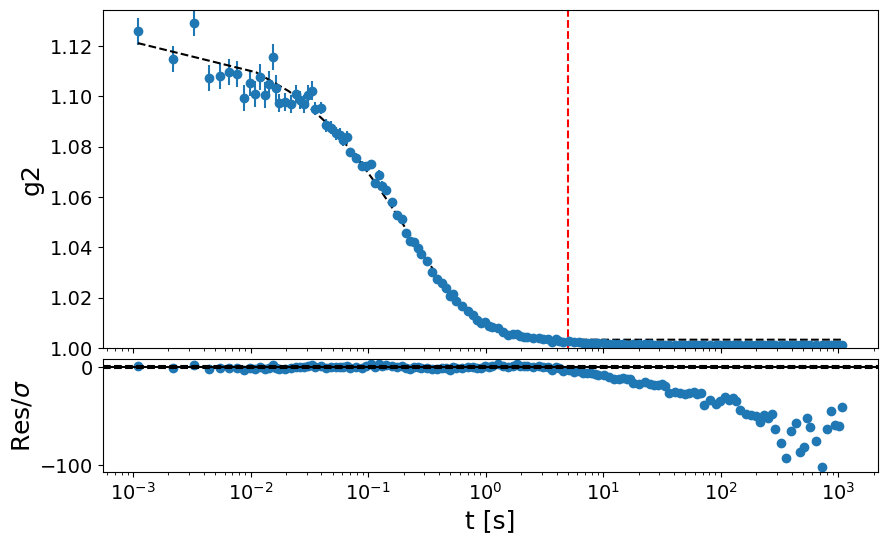

In [39]:
##################
t1_fit = 0
t2_fit = 5
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=10.25keV, T=30C, Q=0.16, th=2.4, 20min @ 1ms ON fp (GeO2_4_10p25, dataset 1, scan 16)

In [40]:
#######################################
sample_name = 'GeO2_4_10p25'
Ndataset = 1
Nscan = 16
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_1025 * Qmask_1025 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 10.25000164635837
itime = 0.0011
theta = 1.7500000000000004
Q = 0.16
th = 2.3999999999999986
T = 22.25 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/243 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/243 loops)
	 -> loading file eiger4m_v

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



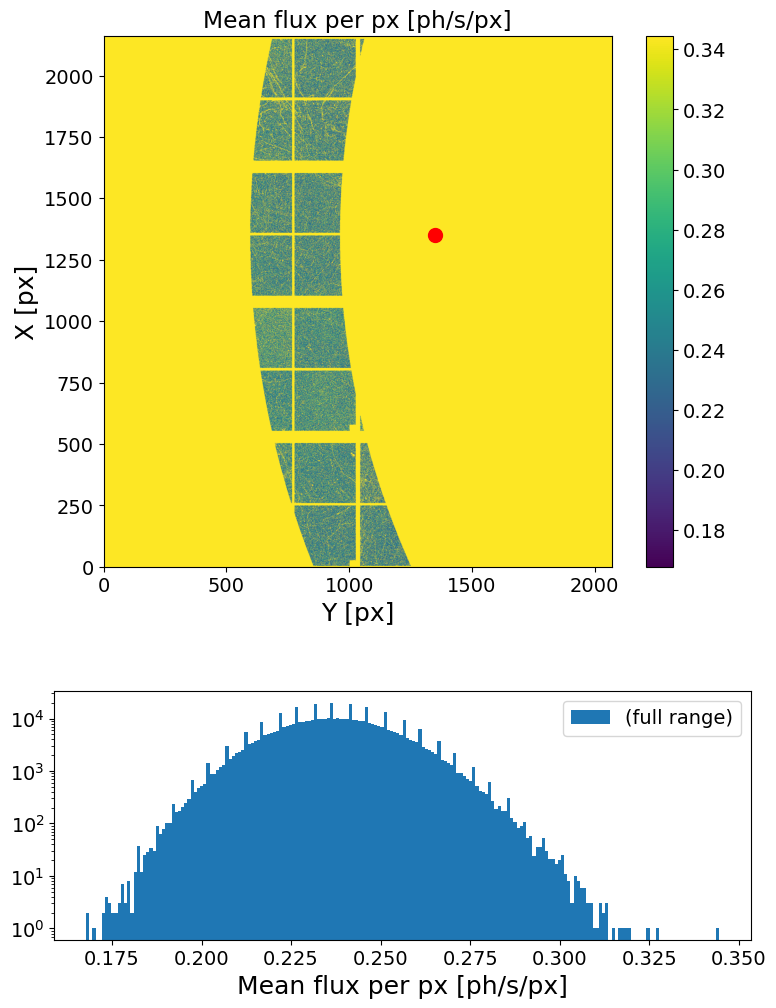

In [41]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [42]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

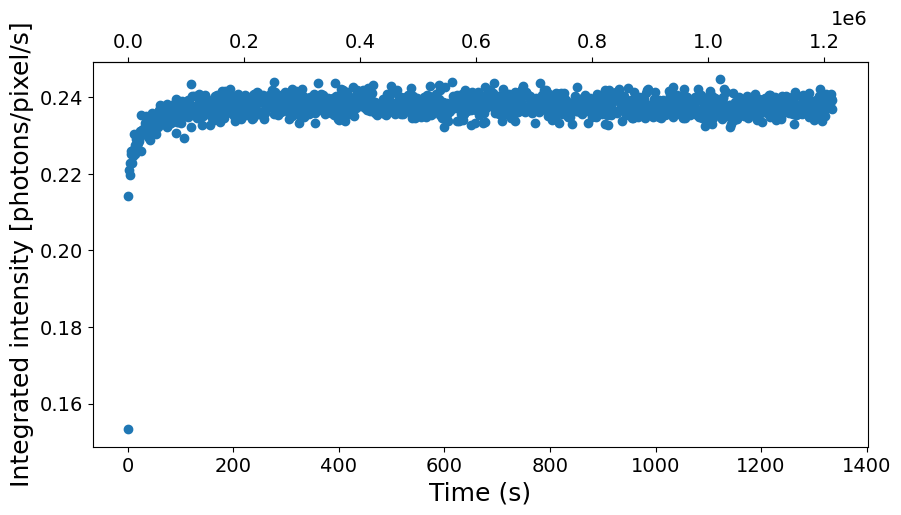

In [43]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [44]:
##### INPUTS #####
Nfi = int(.6e2)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1212476 => (Nff-Nfi) = 74*2^sparse_depth, thrown frames = 1342 (0.11%)
Loading frames ...
Done! (elapsed time = 3.58 s)
	 | 1212416 frames X 528008 pixels
	 | sparsity = 2.61e-04
	 | memory usage (sparse.csr_array @ float32) = 1.878 GB
Computing sparse multitau G2t...


100%|██████████| 74/74 [02:29<00:00,  2.02s/it]


Done! (elapsed time = 149.64 s)
Computing dense multitau G2t...
	-> computing channels on 592 frames ...
	-> computing channels on 296 frames ...
	-> computing channels on 148 frames ...
	-> computing channels on 74 frames ...
	-> computing channels on 37 frames ...
	-> computing channels on 18 frames ...
Done! (elapsed time = 17.17 s)


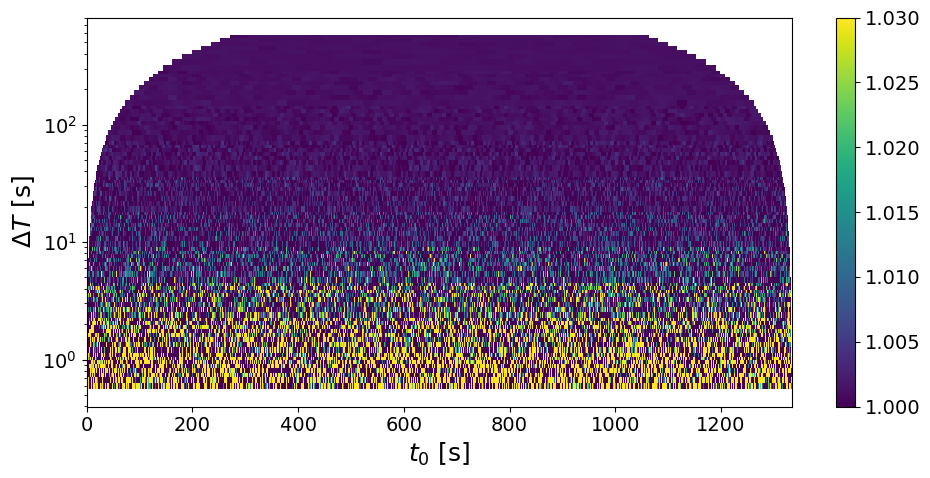

In [45]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.164248,0.010656,6.487851,0.556677,0.016094,2.891105,0.14089,0.004304,3.054612,1.001236,0.000008,0.000762,4.272369


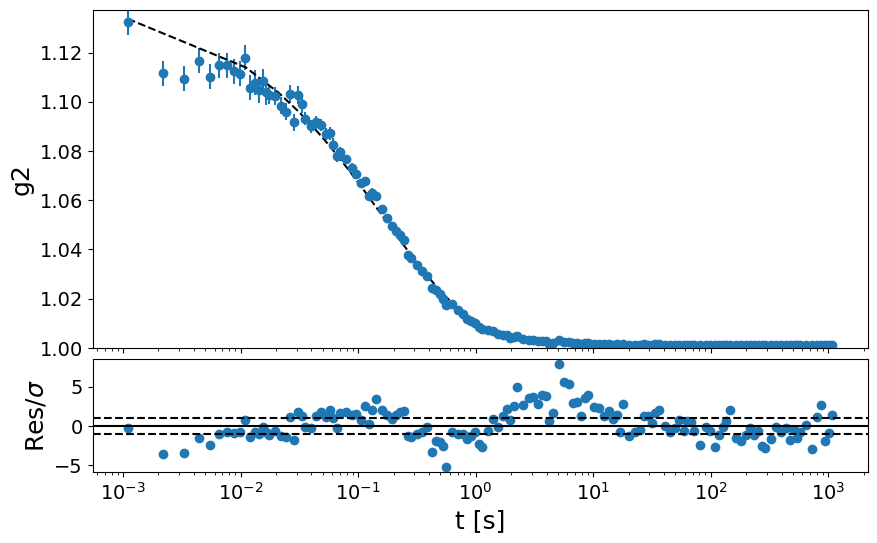

In [46]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=10.25keV, T=30C, Q=0.16, th=0, 20min @ 1ms ON fsa(GeO2_4_10p25, dataset 1, scan 17)

In [47]:
#######################################
sample_name = 'GeO2_4_10p25'
Ndataset = 1
Nscan = 17
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_1025 * Qmask_1025 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 10.25000164635837
itime = 0.0011
theta = 1.7500000000000004
Q = 0.16
th = 0.0
T = 23.65 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/259 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



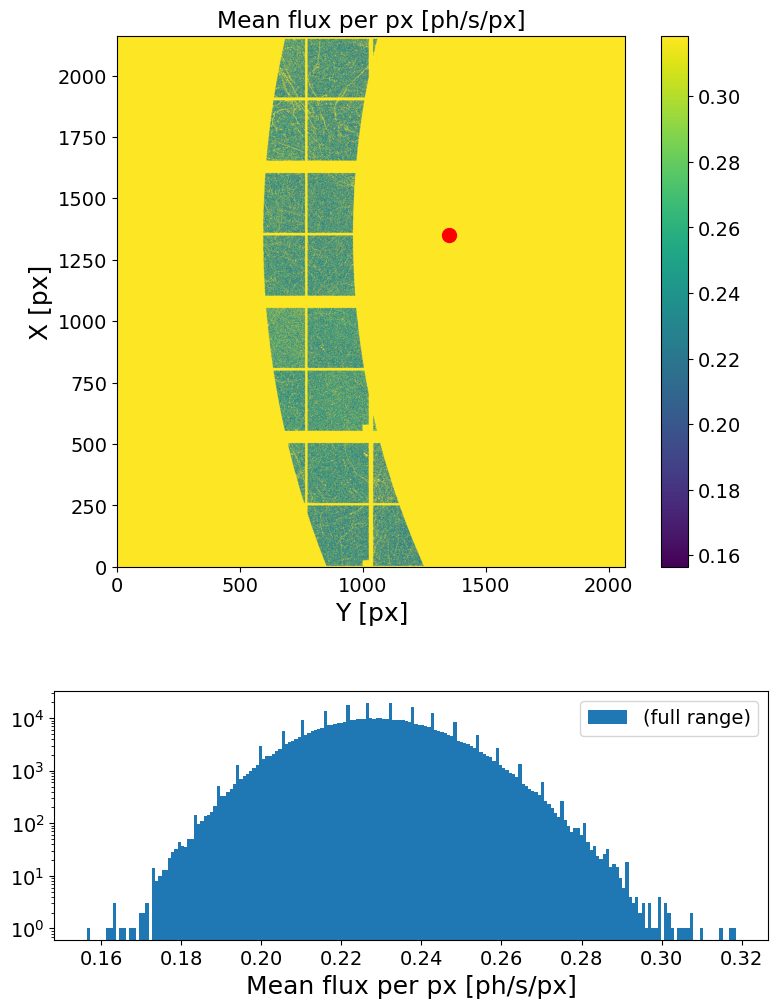

In [48]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [49]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

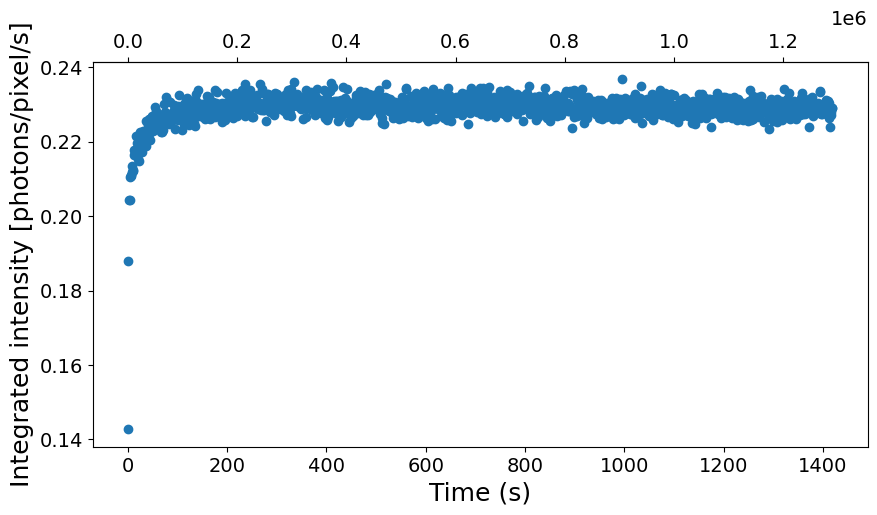

In [50]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [51]:
##### INPUTS #####
Nfi = int(.6e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1288128 => (Nff-Nfi) = 42*2^sparse_depth, thrown frames = 2050 (0.3%)
Loading frames ...
Done! (elapsed time = 0.62 s)
	 | 688128 frames X 528008 pixels
	 | sparsity = 2.52e-04
	 | memory usage (sparse.csr_array @ float32) = 1.03 GB
Computing sparse multitau G2t...


100%|██████████| 42/42 [00:43<00:00,  1.05s/it]


Done! (elapsed time = 43.98 s)
Computing dense multitau G2t...
	-> computing channels on 336 frames ...
	-> computing channels on 168 frames ...
	-> computing channels on 84 frames ...
	-> computing channels on 42 frames ...
	-> computing channels on 21 frames ...
Done! (elapsed time = 5.22 s)


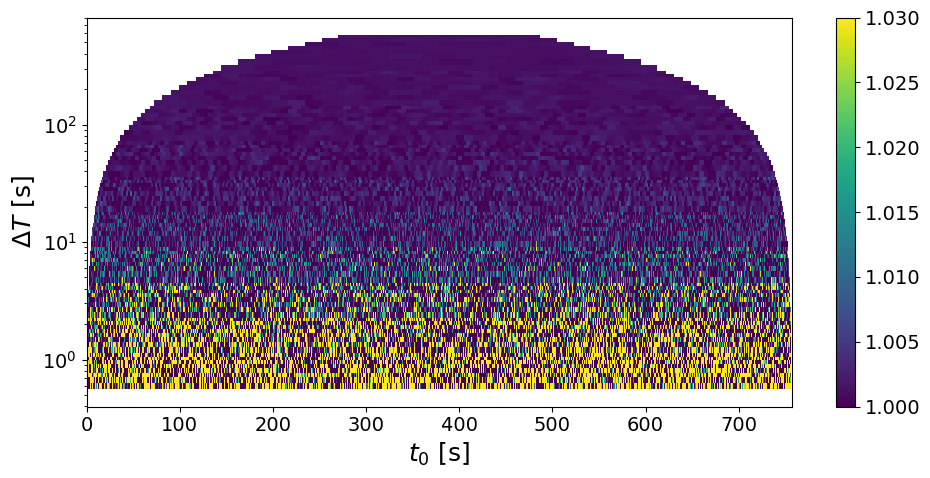

In [52]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.157916,0.013915,8.811872,0.532819,0.019594,3.677399,0.14453,0.005825,4.030498,1.001247,0.000021,0.002094,3.775526


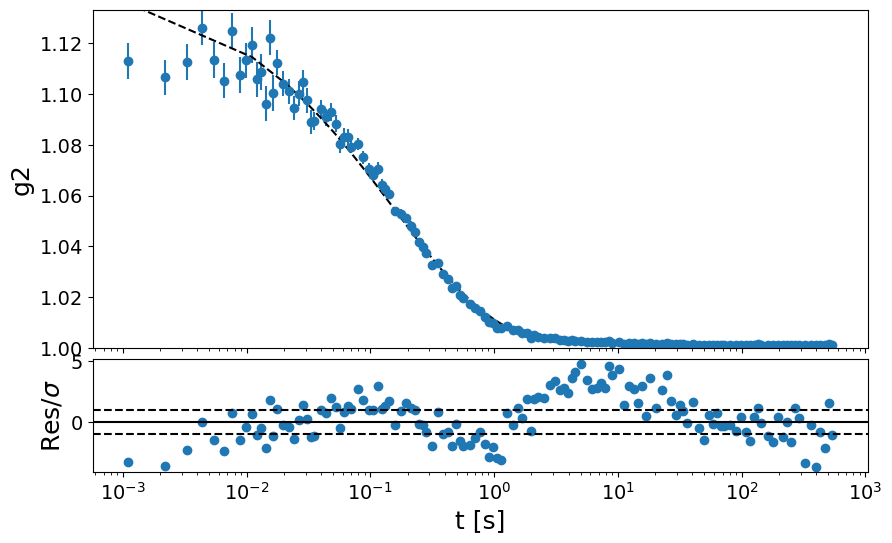

In [53]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

# XPCS scans @ 8.67keV

### Beamstop mask

In [54]:
#######################################
sample_name = 'GeO2_4_8p67'
Ndataset = 1
Nscan = 6
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1200192
Ei = 8.669998877636312
itime = 0.0011
theta = 2.0000000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 11.46 s)
Concatenating vectors ...
Done! (elapsed time = 0.0 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_4_8p67/GeO2_4_8p67_0001/scan0006/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     1.5e-04
	 | Memory usage (scipy.csr_array): 0.007 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 251.0
# of pixels above Ith_high treshold ->  604681 pixels (of 4471016 => 13.52 %)
################################################################################



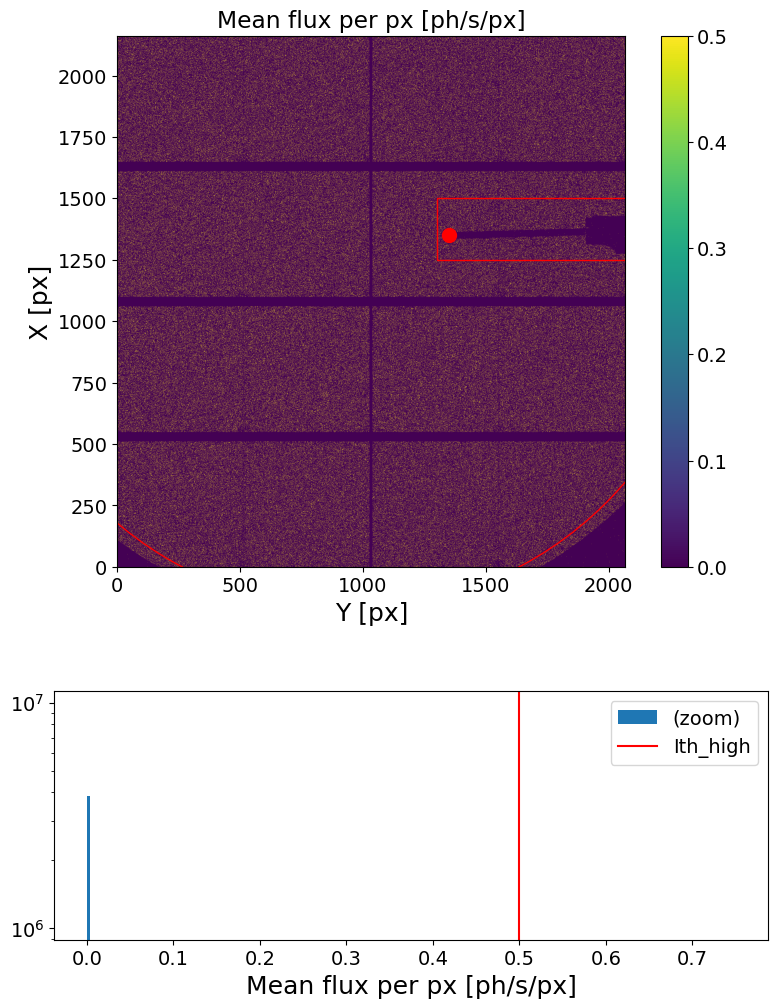

In [55]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



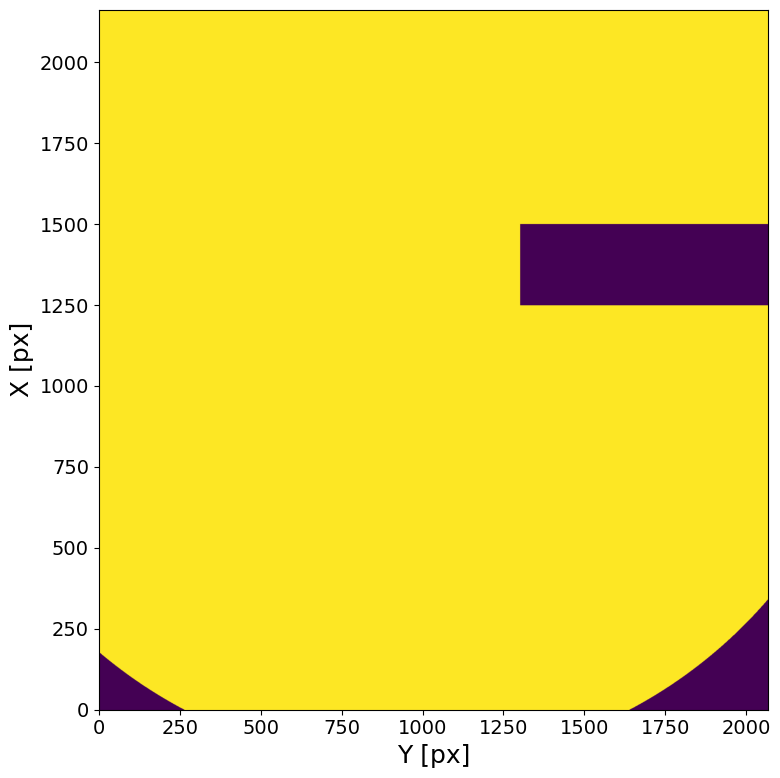

In [56]:
bs_mask_867 = XPCS.gen_mask(mask_geom=geom)

### Q mask

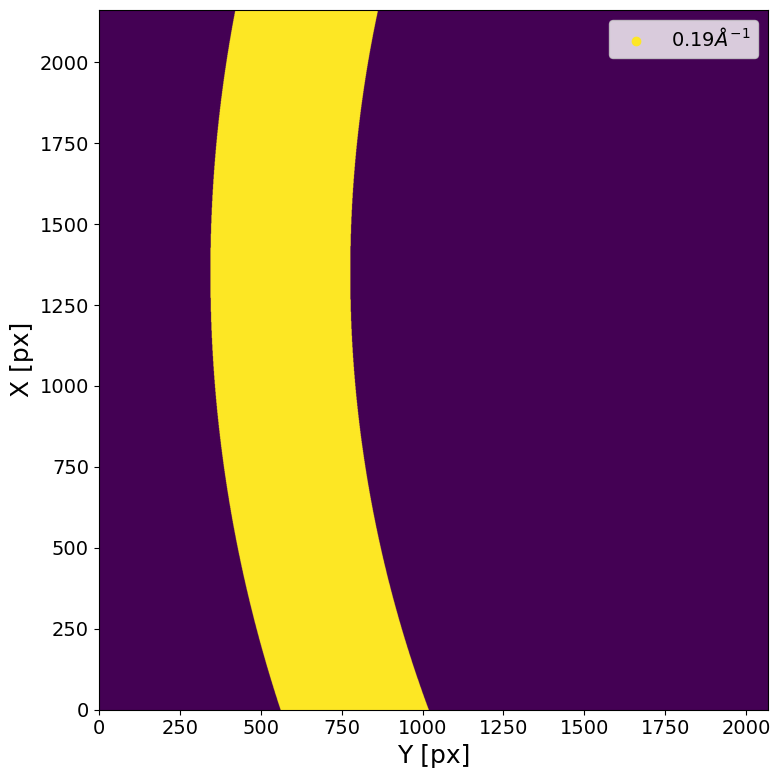

In [57]:
###################
Q_notebook = .19 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask_867 = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

## XPCS scan: Ei=8.67keV, T=30C, Q=0.15, 20min @ 1ms (GeO2_4_8p67, dataset 1, scan 6)

In [58]:
#######################################
sample_name = 'GeO2_4_8p67'
Ndataset = 1
Nscan = 6
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_867 * Qmask_867 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 8.669998877636312
itime = 0.0011
theta = 2.0000000000000004
Q = 0.15
th = 0.0
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



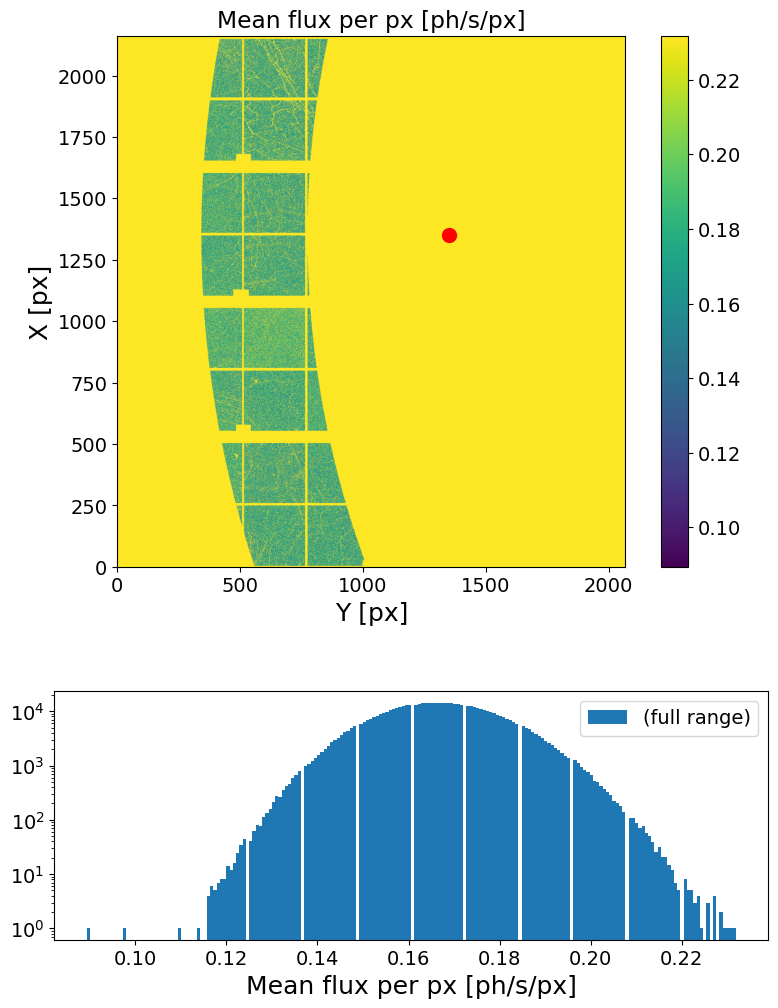

In [59]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [60]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

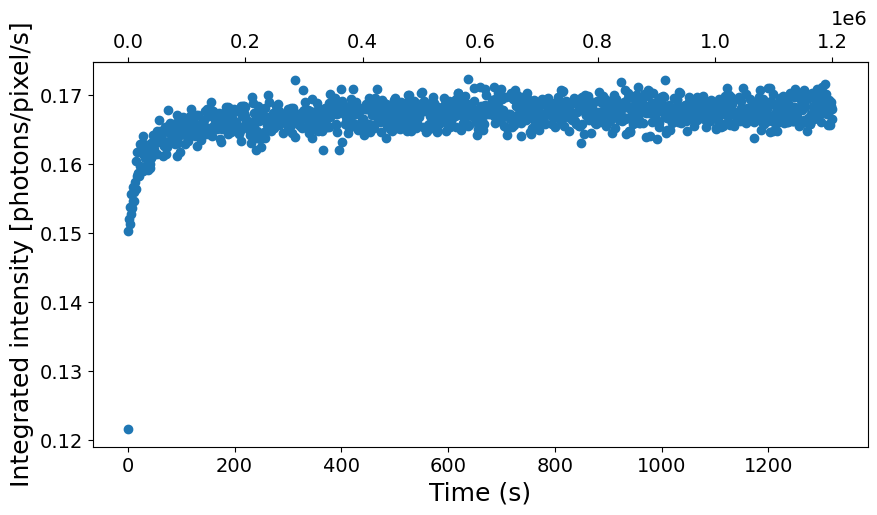

In [61]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [62]:
##### INPUTS #####
Nfi = int(.6e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1189824 => (Nff-Nfi) = 36*2^sparse_depth, thrown frames = 10367 (1.73%)
Loading frames ...
Done! (elapsed time = 1.28 s)
	 | 589824 frames X 616430 pixels
	 | sparsity = 1.85e-04
	 | memory usage (sparse.csr_array @ float32) = 0.755 GB
Computing sparse multitau G2t...


100%|██████████| 36/36 [00:56<00:00,  1.56s/it]


Done! (elapsed time = 56.3 s)
Computing dense multitau G2t...
	-> computing channels on 288 frames ...
	-> computing channels on 144 frames ...
	-> computing channels on 72 frames ...
	-> computing channels on 36 frames ...
	-> computing channels on 18 frames ...
Done! (elapsed time = 7.99 s)


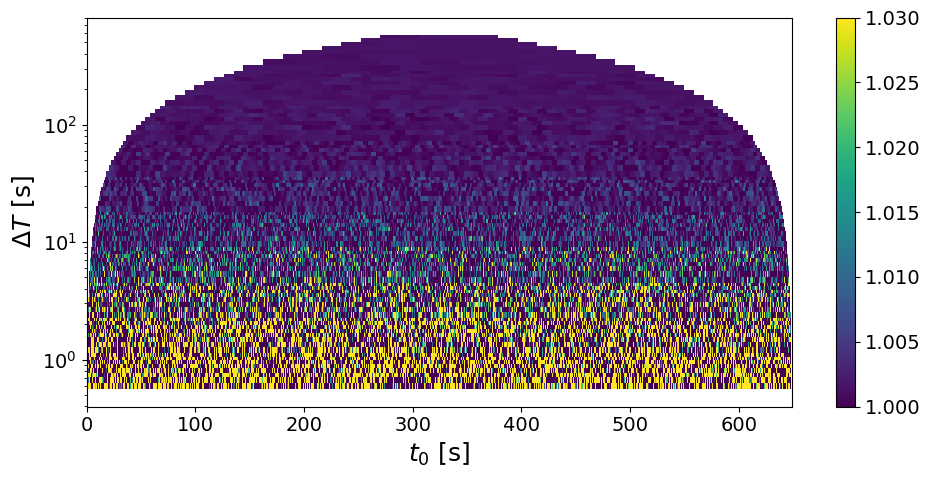

In [63]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.106286,0.013304,12.517558,0.50576,0.024263,4.797435,0.17985,0.009989,5.554102,1.001506,0.000027,0.002702,3.600581


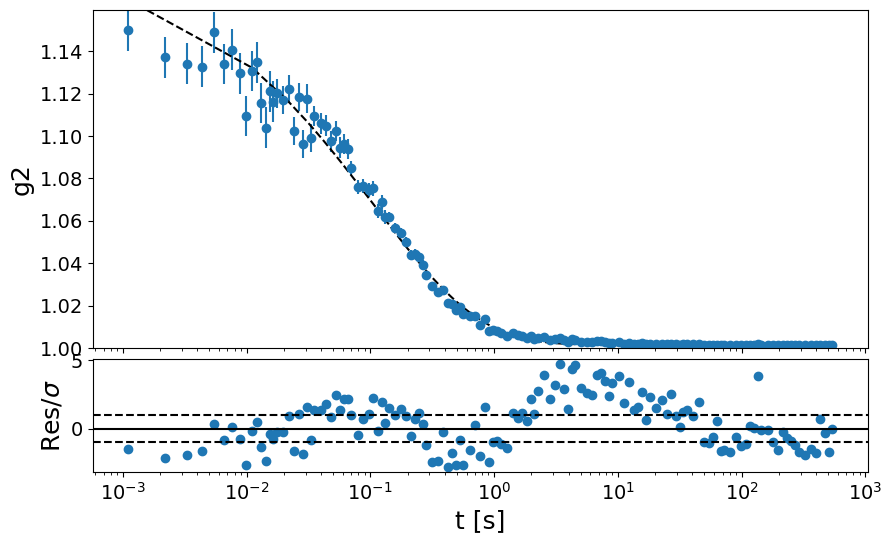

In [64]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.1, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=8.67keV, T=30C, Q=0.15, 20min @ 1ms (GeO2_4_8p67, dataset 1, scan 7)

In [65]:
#######################################
sample_name = 'GeO2_4_8p67'
Ndataset = 1
Nscan = 7
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_867 * Qmask_867 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 8.669998877636312
itime = 0.0011
theta = 2.0000000000000004
Q = 0.15
th = 0.0
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



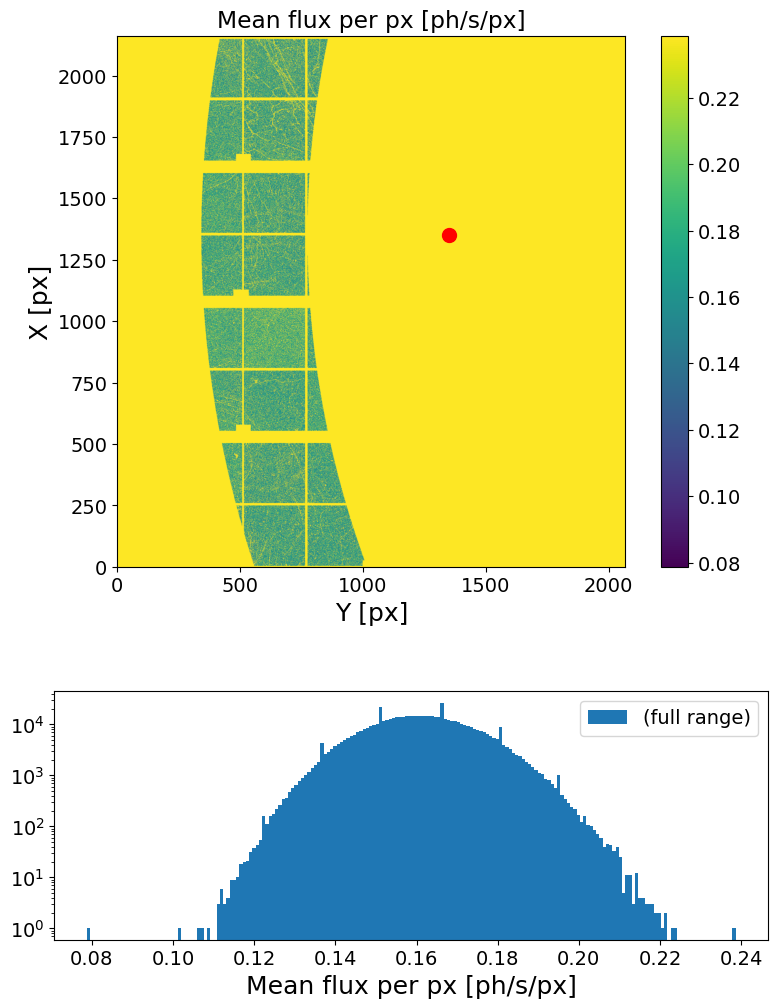

In [66]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [67]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

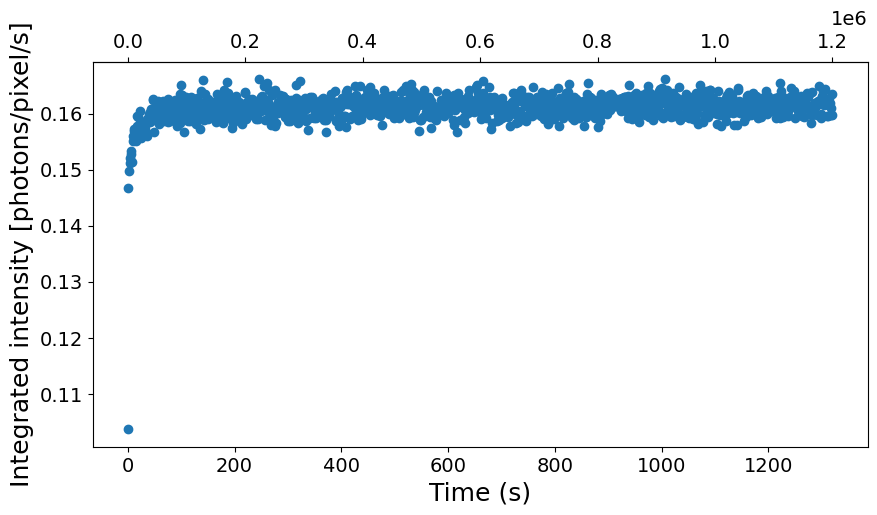

In [68]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [69]:
##### INPUTS #####
Nfi = int(.6e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1189824 => (Nff-Nfi) = 36*2^sparse_depth, thrown frames = 10367 (1.73%)
Loading frames ...
Done! (elapsed time = 1.12 s)
	 | 589824 frames X 616430 pixels
	 | sparsity = 1.78e-04
	 | memory usage (sparse.csr_array @ float32) = 0.726 GB
Computing sparse multitau G2t...


100%|██████████| 36/36 [01:05<00:00,  1.83s/it]


Done! (elapsed time = 65.93 s)
Computing dense multitau G2t...
	-> computing channels on 288 frames ...
	-> computing channels on 144 frames ...
	-> computing channels on 72 frames ...
	-> computing channels on 36 frames ...
	-> computing channels on 18 frames ...
Done! (elapsed time = 7.23 s)


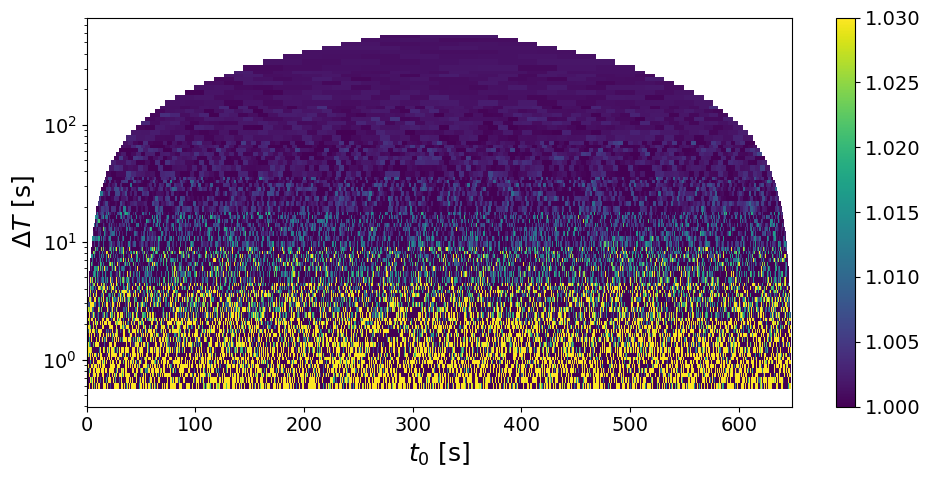

In [70]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.113267,0.011638,10.275178,0.526832,0.022069,4.189038,0.174175,0.008151,4.679957,1.001412,0.000024,0.002414,2.488053


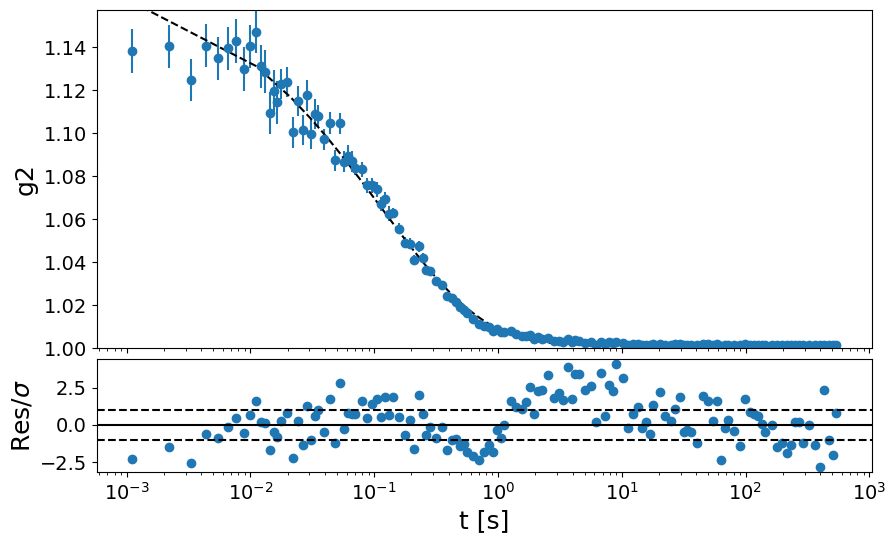

In [71]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.1, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=8.67keV, T=30C, Q=0.15, 20min @ 1ms (GeO2_4_8p67, dataset 1, scan 8)

In [72]:
#######################################
sample_name = 'GeO2_4_8p67'
Ndataset = 1
Nscan = 8
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_867 * Qmask_867 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1200192
Ei = 8.669998877636312
itime = 0.0011
theta = 2.0000000000000004
Q = 0.15
th = 0.0
T = 22.00 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/241 loops)
	 -> loading file eiger4m_v2_sparse_frame_

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



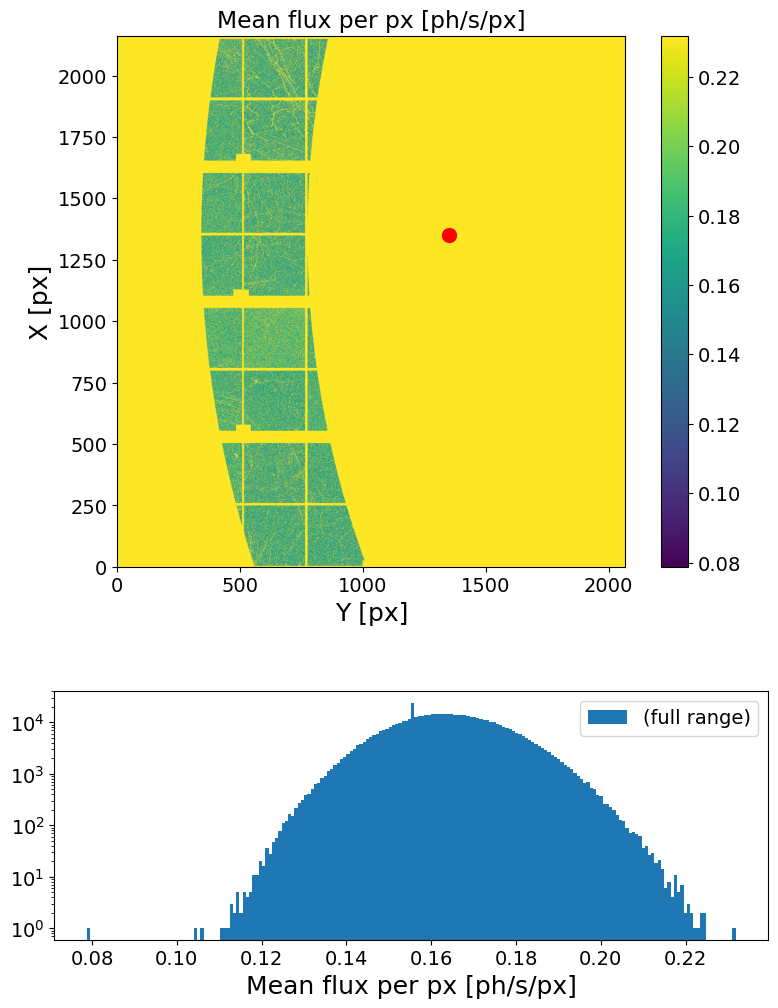

In [73]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [74]:
####################
Lbin = 100
Nstep = 1000
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

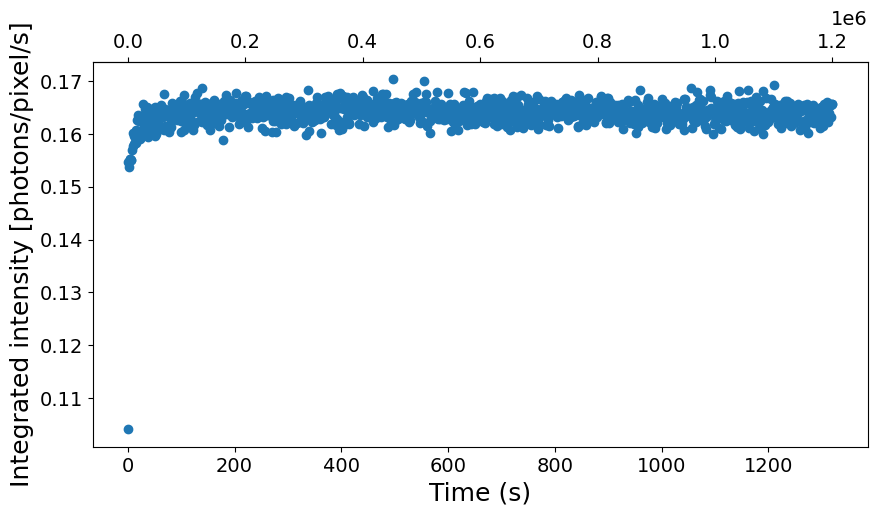

In [75]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Multitau correlation of damaged-vGeO2

In [76]:
##### INPUTS #####
Nfi = int(.2e6)
Nff = None
sparse_depth = 14
ch_depth = 4
mask = None
##################

G2tmt = XPCS.get_G2tmt_4sparse(e4m_data, sparse_depth, ch_depth=ch_depth, mask=None, Nfi=Nfi, Nff=Nff)
g2mt= np.vstack(XPCS.get_g2mt(itime, G2tmt))
np.savetxt(f"{g24damaged_vGeO2_folder}g2mt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2mt)

Nff set to 1199424 => (Nff-Nfi) = 61*2^sparse_depth, thrown frames = 767 (0.08%)
Loading frames ...
Done! (elapsed time = 1.13 s)
	 | 999424 frames X 616430 pixels
	 | sparsity = 1.81e-04
	 | memory usage (sparse.csr_array @ float32) = 1.251 GB
Computing sparse multitau G2t...


100%|██████████| 61/61 [01:06<00:00,  1.08s/it]


Done! (elapsed time = 66.2 s)
Computing dense multitau G2t...
	-> computing channels on 488 frames ...
	-> computing channels on 244 frames ...
	-> computing channels on 122 frames ...
	-> computing channels on 61 frames ...
	-> computing channels on 30 frames ...
Done! (elapsed time = 11.27 s)


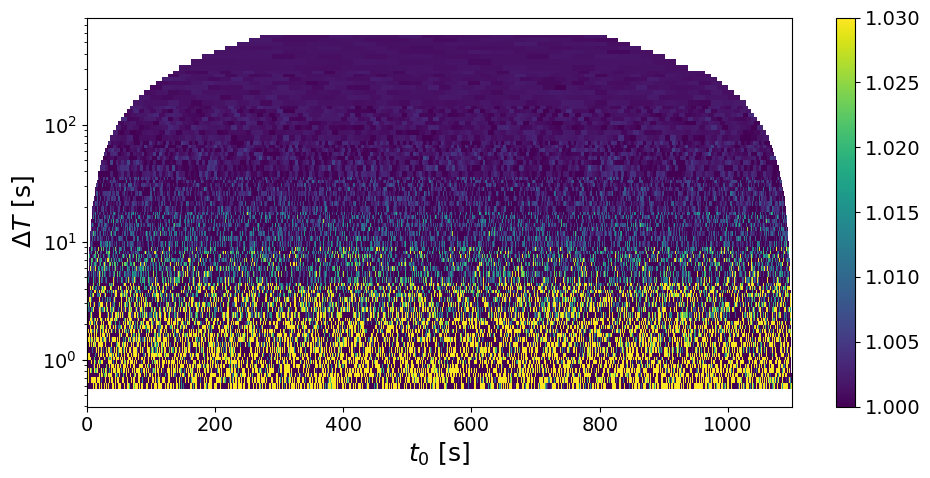

In [77]:
############################
vmin, vmax = 1.0, 1.03
lower_corr = 6
upper_corr = 16
filter_layer = 0
############################

XPCS.plot_G2tmt(G2tmt, itime, vmin, vmax, yscale='log', lower_corr=lower_corr, upper_corr=upper_corr, filter_layer=filter_layer, borders=False)

Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.19,0.01,0.126517,0.00759,5.998799,0.619568,0.020063,3.238204,0.159093,0.004889,3.072942,1.002761,0.000123,0.012225,2.077375


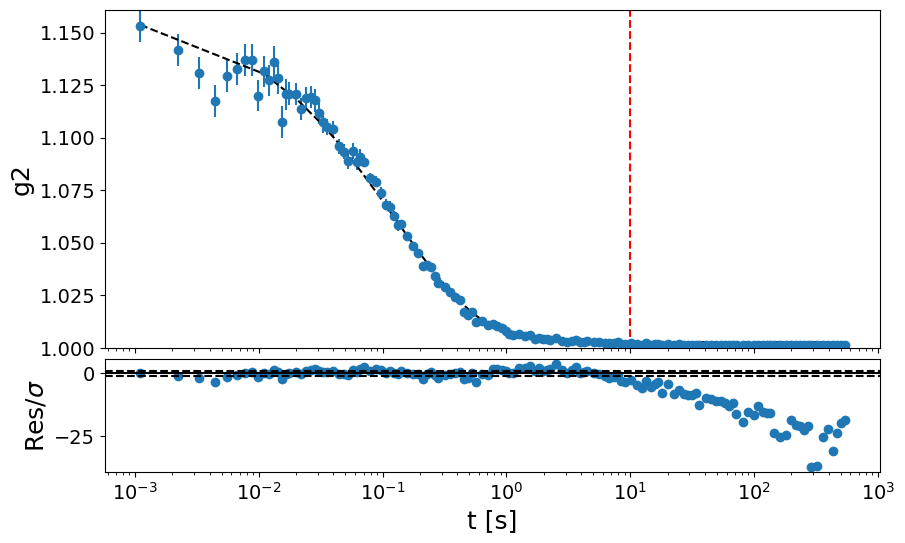

In [78]:
##################
t1_fit = 0
t2_fit = 1e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=.1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.1, min=0, max=.5)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = MTplotfit_4damaged_vGeO2(itime, g2mt, t1_fit, t2_fit, save=True)

## XPCS scan: Ei=8.67keV, **delcoup=5**, T=30C, Q=0.38, th=2.7, 20min @ 1ms (GeO2_4_8p67, dataset 1, scan 8)
Perchè a delcoup=5?

In [79]:
#######################################
sample_name = 'GeO2_4_8p67'
Ndataset = 1
Nscan = 9
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask_867 * Qmask_867 # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)
th = scan['th']

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('th =', th)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

#e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
#e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 3599664
Ei = 8.669998877636312
itime = 0.0011
theta = 5.0
Q = 0.38
th = 2.700000000000003
T = 23.86 min
#############################

